# **PROJEKT EKSPLORACYJNA ANALIZA DANYCH** #
**Autor:** Kamil Batorowicz 251124

---
## **Temat: "Czy Polacy tyją szybciej niż rosną ceny?"** ##

Celem niniejszej analizy jest zbadanie korelacji między zmianami cen poszczególnych grup żywności a trendem wzrostu wagi w polskim społeczeństwie w latach 1999–2022.

Wykorzystując dane Głównego Urzędu Statystycznego (ceny detaliczne) oraz modele NCD Risk Factor Collaboration (trendy BMI dla dorosłych i dzieci), projekt weryfikuje hipotezę o ekonomicznych przyczynach otyłości.

**Pliki z danymi:**  
1. `NCD_RisC_Lancet_2024_BMI_age_standardised_Poland.csv` **(dane o otyłości - BMI dla osób dorosłych z podziałem na płeć)**
2. `CENY_1466_CTAB_20251210132654.csv` **(średnie ceny detaliczne jedzenia)**
3. `CENY_1473_CTAB_20251210132959.csv` **(średnia ceny usług i produktów chemicznych)**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

---
### **Wczytanie danych** ###

**Wczytanie pierwszego pliku z BMI**

In [2]:
# BMI dorosli
df_raw = pd.read_csv('NCD_RisC_Lancet_2024_BMI_age_standardised_Poland.csv')

In [3]:
df_raw.head(3)

,Year,Sex,Country/Region/World,ISO,Prevalence of BMI<18.5 kg/m² (underweight),Prevalence of BMI<18.5 kg/m² (underweight) lower 95% uncertainty interval,Prevalence of BMI<18.5 kg/m² (underweight) upper 95% uncertainty interval,Prevalence of BMI>=30 kg/m² (obesity),Prevalence of BMI>=30 kg/m² (obesity) lower 95% uncertainty interval,Prevalence of BMI>=30 kg/m² (obesity) upper 95% uncertainty interval,...,Prevalence of BMI 25 kg/m² to <30 kg/m² upper 95% uncertainty interval,Prevalence of BMI 30 kg/m² to <35 kg/m²,Prevalence of BMI 30 kg/m² to <35 kg/m² lower 95% uncertainty interval,Prevalence of BMI 30 kg/m² to <35 kg/m² upper 95% uncertainty interval,Prevalence of BMI 35 kg/m² to <40 kg/m²,Prevalence of BMI 35 kg/m² to <40 kg/m² lower 95% uncertainty interval,Prevalence of BMI 35 kg/m² to <40 kg/m² upper 95% uncertainty interval,Prevalence of BMI >=40 kg/m² (morbid obesity),Prevalence of BMI >=40 kg/m² (morbid obesity) lower 95% uncertainty interval,Prevalence of BMI >=40 kg/m² (morbid obesity) upper 95% uncertainty interval
0,1990,Women,Poland,POL,0.034151,0.024333,0.045678,0.171895,0.151002,0.194589,...,0.317105,0.123621,0.103889,0.144927,0.038108,0.029156,0.048418,0.010166,0.006929,0.014370
1,1991,Women,Poland,POL,0.034872,0.025485,0.045919,0.171848,0.152026,0.193609,...,0.314605,0.123623,0.104794,0.143886,0.037946,0.029379,0.047595,0.010279,0.007166,0.014210
2,1992,Women,Poland,POL,0.035558,0.026385,0.046213,0.171918,0.152965,0.192301,...,0.312158,0.123700,0.105837,0.143256,0.037821,0.029666,0.047021,0.010397,0.007379,0.014166


---
**Uproszczenie nazw kolumn**    
Widać, że nazwy są długie, aby było czytelniej zmieniamy nazwy na krótsze, ogólniejsze.

In [4]:
# zmiana nazw kolumn oraz wybranie najwazniejszych
new_names = {
    'Country/Region/World': 'Country',
    'Prevalence of BMI<18.5 kg/m² (underweight)': 'Underweight',
    'Prevalence of BMI>=30 kg/m² (obesity)': 'Obesity',
    'Prevalence of BMI 25 kg/m² to <30 kg/m²': 'Overweight',
    'Prevalence of BMI 30 kg/m² to <35 kg/m²': 'Obesity_Class1',
    'Prevalence of BMI 35 kg/m² to <40 kg/m²': 'Obesity_Class2',
    'Prevalence of BMI >=40 kg/m² (morbid obesity)': 'Morbid_Obesity'
}

df_bmi_adult = df_raw.rename(columns=new_names)
keep_cols = ['Year', 'Sex', 'Country', 'Underweight', 'Overweight', 'Obesity', 'Obesity_Class1', 'Obesity_Class2', 'Morbid_Obesity']
final_cols = [c for c in keep_cols if c in df_bmi_adult.columns]
df_bmi_adult = df_bmi_adult[final_cols]

df_obesity_mean = df_bmi_adult.groupby('Year')['Obesity'].mean() * 100
df_obesity_mean.name = 'Otylosc_Proc'

df_bmi_adult.head(3)

,Year,Sex,Country,Underweight,Overweight,Obesity,Obesity_Class1,Obesity_Class2,Morbid_Obesity
0,1990,Women,Poland,0.034151,0.289194,0.171895,0.123621,0.038108,0.010166
1,1991,Women,Poland,0.034872,0.288085,0.171848,0.123623,0.037946,0.010279
2,1992,Women,Poland,0.035558,0.287079,0.171918,0.123700,0.037821,0.010397


In [5]:
df_bmi_adult.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 66 entries, 0 to 65
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Year            66 non-null     int64  
 1   Sex             66 non-null     object 
 2   Country         66 non-null     object 
 3   Underweight     66 non-null     float64
 4   Overweight      66 non-null     float64
 5   Obesity         66 non-null     float64
 6   Obesity_Class1  66 non-null     float64
 7   Obesity_Class2  66 non-null     float64
 8   Morbid_Obesity  66 non-null     float64
dtypes: float64(6), int64(1), object(2)
memory usage: 4.8+ KB


---
**Wczytanie drugiego pliku z żywnością**

In [6]:
# ŻYWNOŚĆ
df_raw = pd.read_csv('CENY_1466_CTAB_20251210132654.csv', sep=';', dtype=str)

In [7]:
df_raw.head(3)

,Kod,Nazwa,ryż - za 1kg;1999;[zł],ryż - za 1kg;2000;[zł],ryż - za 1kg;2001;[zł],ryż - za 1kg;2002;[zł],ryż - za 1kg;2003;[zł],ryż - za 1kg;2004;[zł],ryż - za 1kg;2005;[zł],ryż - za 1kg;2006;[zł],...,sok wieloowocowy (1) - za 300ml;2016;[zł],sok wieloowocowy (1) - za 300ml;2017;[zł],sok wieloowocowy (1) - za 300ml;2018;[zł],sok wieloowocowy (1) - za 300ml;2019;[zł],sok wieloowocowy (1) - za 300ml;2020;[zł],sok wieloowocowy (1) - za 300ml;2021;[zł],sok wieloowocowy (1) - za 300ml;2022;[zł],sok wieloowocowy (1) - za 300ml;2023;[zł],sok wieloowocowy (1) - za 300ml;2024;[zł],Unnamed: 2056
0,0000000,POLSKA,"2,43","2,39","2,29","2,12","1,98","2,59","2,74","2,63",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"4,24","4,47",NaN


---
**Funkcja clean_gus_data**   
Służy do wstępnego przetwarzania i czyszczenia danych pochodzących z plików CSV. Jej głównym celem jest przekształcenie "surowego" formatu, w jakim GUS udostępnia dane (często z nietypowymi nagłówkami i formatowaniem liczb), w przejrzystą ramkę danych biblioteki pandas, gotową do analizy.

In [8]:
def clean_gus_data(df):
    data_dict = {}
    row = df.iloc[0]
    
    for col_name, value in row.items():
        if ';' in col_name:
            parts = col_name.split(';')
            if len(parts) >= 2:
                product_name = parts[0].strip()
                year_str = parts[1].strip() 
                
                if year_str.isdigit():
                    year = int(year_str)
                    
                    if isinstance(value, str):
                        value = value.replace(',', '.').replace(' ', '')
                    
                    try:
                        price = float(value)
                    except (ValueError, TypeError):
                        price = np.nan
                    
                    if year not in data_dict:
                        data_dict[year] = {}
                    data_dict[year][product_name] = price

    df_clean = pd.DataFrame.from_dict(data_dict, orient='index')
    df_clean.index.name = 'Year'
    df_clean = df_clean.sort_index()
    return df_clean

df_food = clean_gus_data(df_raw)
display(df_food.head(3))

,ryż - za 1kg,bułka pszenna - za 50g,bułka pszenna mała wagi do 60g – za 1 szt.,"chleb żytni razowy zwykły - za 0,5kg",mąka pszenna (1) - za 1kg,chleb żytni razowy zwykły - za 1kg,chleb żytni razowy - za 1kg,"chleb pszenno-żytni - za 0,5kg",musli zbożowe z dodatkami (np. owoców) - za 350g,"chleb pszenno-żytni 0,6kg",...,sok jabłkowy - za 1l,sok wieloowocowy - za 175ml,sok wieloowocowy - za 300ml,kawa naturalna mielona (1) - za 250g,mięso wołowe z kością - za 1kg,szynka wieprzowa - za 1kg,"konserwa mięsna, w puszce - za 300g",ser twarogowy - za 1kg,miód pszczeli (1) - za 400g,sok wieloowocowy (1) - za 300ml
Year,,,,,,,,,,,,,,,,,,,,,
1999,2.43,0.23,NaN,NaN,NaN,2.21,NaN,NaN,NaN,1.20,...,2.91,1.37,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2000,2.39,0.27,NaN,1.35,NaN,NaN,NaN,NaN,NaN,1.43,...,3.33,1.46,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2001,2.29,0.30,NaN,1.49,NaN,NaN,NaN,1.45,NaN,NaN,...,3.32,1.57,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


---
**Łączenie kolumn**   
Ten fragment kodu służy do ujednolicania i czyszczenia danych o cenach.   
W danych zdarza się, że zmieniają się definicje produktów (np. kiedyś badano chleb 0.5kg, a potem zaczęto badać 0.6kg). Ten kod łączy te pocięte kawałki historii w jedną ciągłą kolumnę.

In [9]:
# łączenie kolumn
def merge_products(df, columns_list):
    base_col = pd.Series(np.nan, index=df.index)
    for col in columns_list:
        if col in df.columns:
            base_col = base_col.fillna(df[col])
    return base_col

df_prices = pd.DataFrame(index=df_food.index)

In [10]:
cols_bread = ['chleb pszenno-żytni - za 0,5kg', 'chleb pszenno-żytni 0,6kg']
df_prices['Chleb'] = merge_products(df_food, cols_bread)

cols_ham = ['szynka wieprzowa gotowana - za 1kg', 'szynka wieprzowa - za 1kg']
df_prices['Szynka'] = merge_products(df_food, cols_ham)

cols_flour = ['mąka pszenna - za 1kg', 'mąka pszenna (1) - za 1kg']
df_prices['Maka'] = merge_products(df_food, cols_flour)

cols_beef = ['mięso wołowe z kością (rostbef) - za 1kg', 'mięso wołowe z kością - za 1kg']
df_prices['Wolowina'] = merge_products(df_food, cols_beef)

if 'cukier biały kryształ - za 1kg' in df_food.columns:
    df_prices['Cukier'] = df_food['cukier biały kryształ - za 1kg']

if 'masło świeże o zawartości tłuszczu ok. 82,5% - za 200g' in df_food.columns:
    df_prices['Maslo'] = df_food['masło świeże o zawartości tłuszczu ok. 82,5% - za 200g']

if 'sok jabłkowy - za 1l' in df_food.columns:
    df_prices['Sok_Jablkowy'] = df_food['sok jabłkowy - za 1l']

df_prices.head(3)

,Chleb,Szynka,Maka,Wolowina,Cukier,Maslo,Sok_Jablkowy
Year,,,,,,,
1999,1.20,17.39,1.48,8.93,1.95,2.26,2.91
2000,1.43,18.89,1.60,9.87,2.97,2.88,3.33
2001,1.45,20.34,1.70,10.59,2.52,2.35,3.32


---
**Wczytanie trzeciego pliku z usługami**

In [11]:
# USŁUGI I CHEMIA
file_services = 'CENY_1473_CTAB_20251210132959.csv'
df_raw_services = pd.read_csv(file_services, sep=';', dtype=str)

df_services = clean_gus_data(df_raw_services)
df_services.head(3)

,ondulacja na zimno włosów damskich,strzyżenie włosów męskich,mydło toaletowe - za 100g,mydło toaletowe - za 90g,pasta do zębów - za 100ml,pasta do zębów Colgate 50ml,pasta do mycia zębów 50ml,pasta do mycia zębów 75ml,pasta do zębów - za 125ml,krem do golenia - za 65g,krem do golenia 70ml,zegarek męski kwarcowy,zegarek męski kwarcowy bez bransoletki 1szt.,mydło toaletowe - za 90g (1),zegarek męski
Year,,,,,,,,,,,,,,,
1999,39.74,9.28,1.35,NaN,NaN,5.17,NaN,NaN,NaN,NaN,1.95,NaN,54.83,NaN,NaN
2000,43.73,10.31,1.47,NaN,NaN,NaN,5.29,NaN,NaN,NaN,2.20,NaN,59.50,NaN,NaN
2001,46.59,10.79,1.57,NaN,NaN,NaN,NaN,7.05,NaN,NaN,2.39,NaN,64.25,NaN,NaN


---
**Rozszerzenie analizy o chemię i usługi**
* Dodanie usług (fryzjer)
* Dodanie i scalanie chemii
* Interpolacja liniowa (uzupełnienie brakujących danych, np. jeśli mamy cenę w 2000 r. (10 zł) i w 2002 r. (12 zł), ale brakuje 2001 r., to program wstawi tam średnią (11 zł). Rysuje linię prostą między punktami.)

In [12]:
if 'strzyżenie włosów męskich' in df_services.columns:
    df_prices['Fryzjer'] = df_services['strzyżenie włosów męskich']

cols_soap = ['mydło toaletowe - za 100g', 'mydło toaletowe - za 90g', 'mydło toaletowe - za 90g (1)']
df_prices['Mydlo'] = merge_products(df_services, cols_soap)

cols_paste = ['pasta do zębów - za 100ml', 'pasta do mycia zębów 75ml', 'pasta do zębów - za 125ml', 'pasta do zębów Colgate 50ml']
df_prices['Pasta'] = merge_products(df_services, cols_paste)

# interpolacja liniowa (uzupełnienie NaN)
df_prices = df_prices.interpolate(method='linear').ffill().bfill()

df_final = df_prices.join(df_obesity_mean, how='inner')

display(df_prices.head(3))

,Chleb,Szynka,Maka,Wolowina,Cukier,Maslo,Sok_Jablkowy,Fryzjer,Mydlo,Pasta
Year,,,,,,,,,,
1999,1.20,17.39,1.48,8.93,1.95,2.26,2.91,9.28,1.35,5.17
2000,1.43,18.89,1.60,9.87,2.97,2.88,3.33,10.31,1.47,6.11
2001,1.45,20.34,1.70,10.59,2.52,2.35,3.32,10.79,1.57,7.05


---
**Utworzenie wskaźników do użycia na wykresach**   
* Wspólny zakres czasu dla wszystkich danych
* Utworzenie koszyków (średnia cena dla grupy produtków)
* Utworzenie indeksów, by procentowo porównywać dane (by móc porównać dynamikę zmian)

In [13]:
# wspólny zakres dat
start, end = 1999, 2022
df_final = df_prices.loc[start:end].join(df_obesity_mean, how='inner')

# koszyki
df_final['Koszyk_Spozywczy'] = (df_final['Chleb'] + df_final['Maka'] + df_final['Szynka'] + df_final['Wolowina'] + df_final['Cukier'] + df_final['Maslo']) / 6
df_final['Koszyk_Chemia'] = (df_final['Mydlo'] + df_final['Pasta']) / 2

# indeksy
base_year = 1999
df_final['Indeks_Spozywczy'] = (df_final['Koszyk_Spozywczy'] / df_final['Koszyk_Spozywczy'].loc[base_year]) * 100
df_final['Indeks_Chemia'] = (df_final['Koszyk_Chemia'] / df_final['Koszyk_Chemia'].loc[base_year]) * 100
df_final['Indeks_Fryzjer'] = (df_final['Fryzjer'] / df_final['Fryzjer'].loc[base_year]) * 100
df_final['Indeks_Otylosc'] = (df_final['Otylosc_Proc'] / df_final['Otylosc_Proc'].loc[base_year]) * 100

---
## **WYKRESY** ##

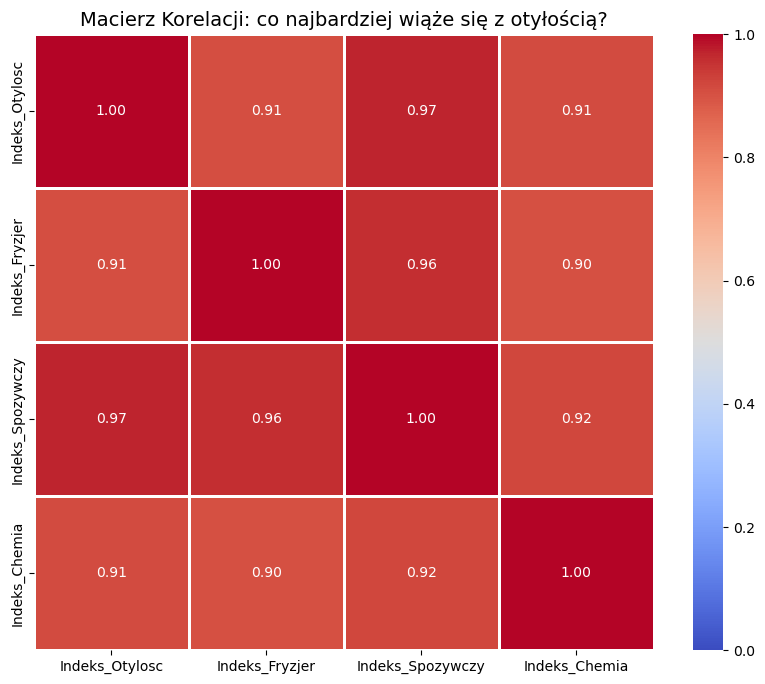

In [14]:
# MACIERZ KORELACJI
cols_to_corr = ['Indeks_Otylosc', 'Indeks_Fryzjer', 'Indeks_Spozywczy', 'Indeks_Chemia']
corr_matrix = df_final[cols_to_corr].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=0, vmax=1, fmt=".2f", linewidths=1)
plt.title('Macierz Korelacji: co najbardziej wiąże się z otyłością?', fontsize=14)
plt.show()

**OBSERWACJE - MACIERZ KORELACJI**   
Najbardziej z otyłością wiąże się Indeks Spożywczy, czyli żywność 0.97). Jednak widać, że wszystkie korelacje są powyżej 0.9, co wynika z silnego wzrostu wszystkich zmiennych w czasie.

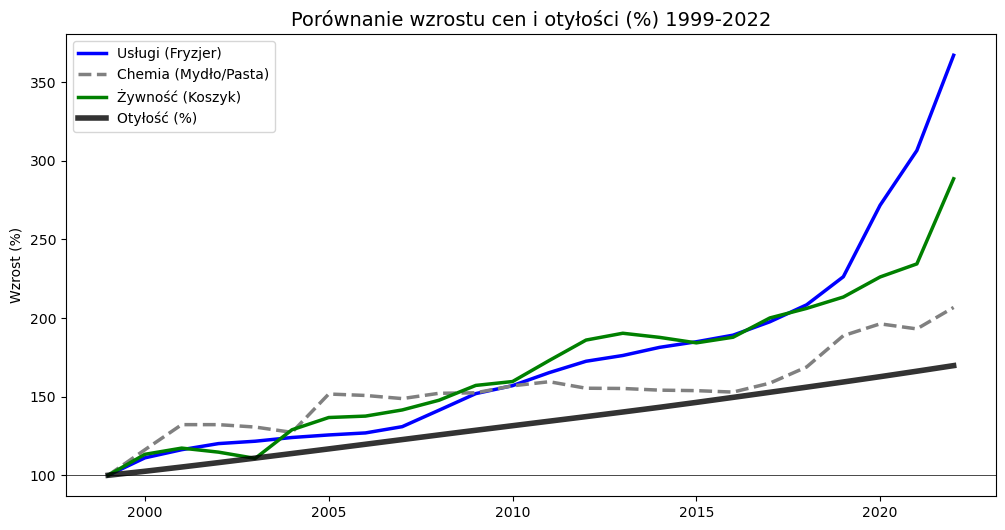

In [15]:
# WYKRES LINIOWY
plt.figure(figsize=(12, 6))
plt.plot(df_final.index, df_final['Indeks_Fryzjer'], label='Usługi (Fryzjer)', color='blue', linewidth=2.5)
plt.plot(df_final.index, df_final['Indeks_Chemia'], label='Chemia (Mydło/Pasta)', color='grey', linewidth=2.5, linestyle='--')
plt.plot(df_final.index, df_final['Indeks_Spozywczy'], label='Żywność (Koszyk)', color='green', linewidth=2.5)
plt.plot(df_final.index, df_final['Indeks_Otylosc'], label='Otyłość (%)', color='black', linewidth=4, alpha=0.8)

plt.axhline(100, color='black', linewidth=0.5)
plt.title('Porównanie wzrostu cen i otyłości (%) 1999-2022', fontsize=14)
plt.ylabel('Wzrost (%)')
plt.legend()
plt.show()

**OBSERWACJE - WYKRES LINIOWY**   
Wszystkie zmienne rosną w czasie. W ostatnich latach najbardziej podrożał fryzjer, następnie żywność. Chemia również podrożała, jednak mniej. Otyłość rośnie liniowo, pod niedużym nachyleniem w porównaniu do zmiennych (żywności, usług, chemii).

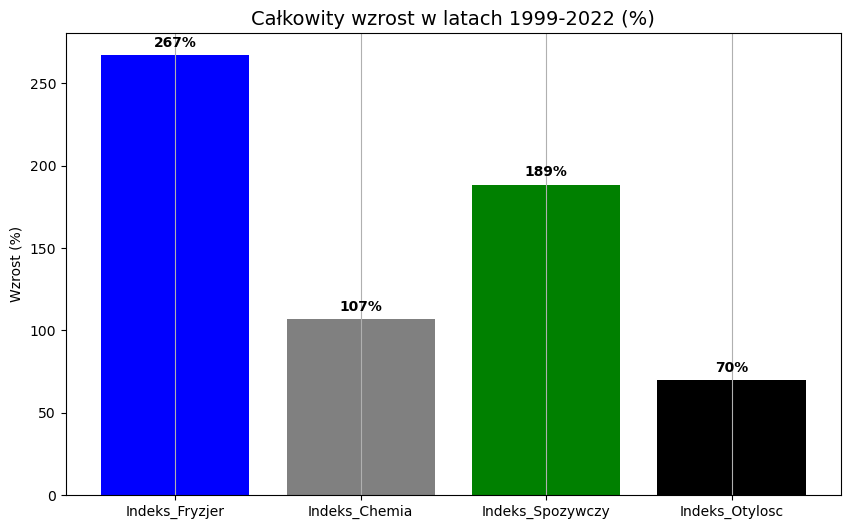

In [16]:
# WYKRES SŁUPKOWY
growth_total = (df_final.iloc[-1] / df_final.iloc[0] - 1) * 100
growth_subset = growth_total[['Indeks_Fryzjer', 'Indeks_Chemia', 'Indeks_Spozywczy', 'Indeks_Otylosc']]

plt.figure(figsize=(10, 6))
bars = plt.bar(growth_subset.index, growth_subset.values, color=['blue', 'grey', 'green', 'black'])
plt.title('Całkowity wzrost w latach 1999-2022 (%)', fontsize=14)
plt.ylabel('Wzrost (%)')
plt.grid(axis='x')

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 5, f"{yval:.0f}%", ha='center', fontweight='bold')
plt.show()

**OBSERWACJE - WYKRES SŁUPKOWY**   
Z wykresu widać, że najbardziej wzrosły usługi (o 267%), chemia oraz produkty spożywcze również podrożały znacząco (o 107% i 189%). Otyłość na przestrzeni lat też wzrosła, lecz względem usług, produktów w mniejszym stopniu (70%).

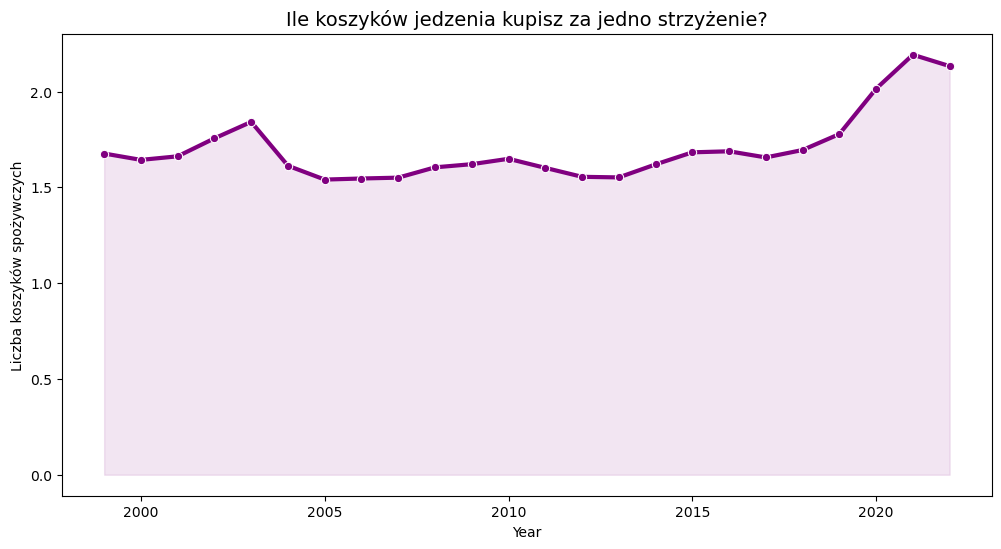

In [17]:
# WYKRES LINIOWY Z WYPEŁNIENIEM - WSKAŹNIK SIŁY NABYWCZEJ (RELACJA USŁUG A ŻYWNOŚCIĄ)
df_final['Sila_Nabywcza'] = df_final['Fryzjer'] / df_final['Koszyk_Spozywczy']

plt.figure(figsize=(12, 6))
sns.lineplot(data=df_final, x=df_final.index, y='Sila_Nabywcza', color='purple', linewidth=3, marker='o')
plt.fill_between(df_final.index, df_final['Sila_Nabywcza'], color='purple', alpha=0.1)
plt.title('Ile koszyków jedzenia kupisz za jedno strzyżenie?', fontsize=14)
plt.ylabel('Liczba koszyków spożywczych')
plt.show()

**OBSERWACJE - WYKRES LINIOWY Z WYPEŁNIENIEM**   
Z wykresu widać, że z czasem za równowartość jednego strzyżenia stopniowo wzrasta ilość koszyków jedzenia, które można kupić.

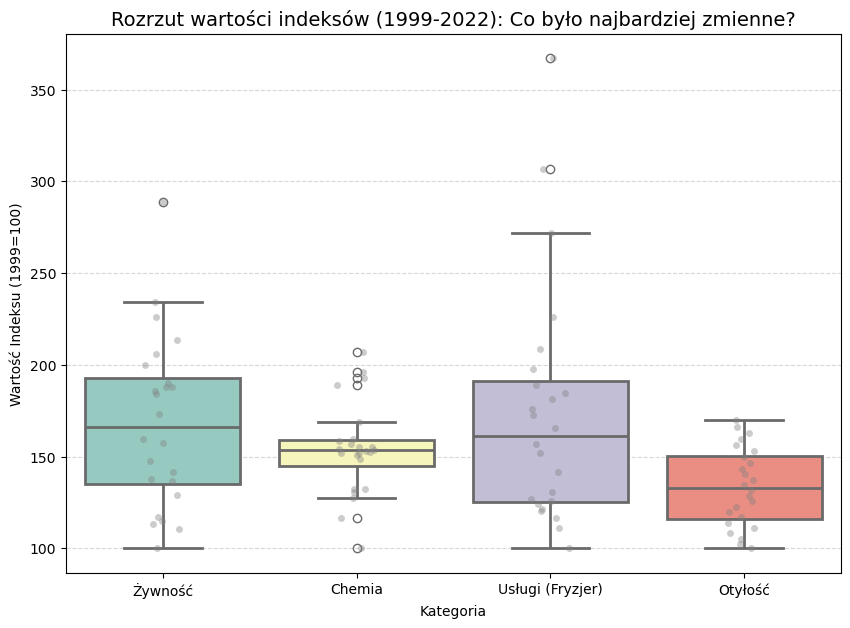

In [18]:
# WYKRES PUDEŁKOWY
cols_to_plot = ['Indeks_Spozywczy', 'Indeks_Chemia', 'Indeks_Fryzjer', 'Indeks_Otylosc']
df_melted = df_final[cols_to_plot].melt(var_name='Kategoria', value_name='Wartość Indeksu')

labels_map = {
    'Indeks_Spozywczy': 'Żywność',
    'Indeks_Chemia': 'Chemia',
    'Indeks_Fryzjer': 'Usługi (Fryzjer)',
    'Indeks_Otylosc': 'Otyłość'
}
df_melted['Kategoria'] = df_melted['Kategoria'].map(labels_map)

plt.figure(figsize=(10, 7))

sns.boxplot(data=df_melted, x='Kategoria', y='Wartość Indeksu', hue='Kategoria', legend=False, palette='Set3', linewidth=2)
sns.stripplot(data=df_melted, x='Kategoria', y='Wartość Indeksu', color='grey', alpha=0.4, jitter=True)

plt.title('Rozrzut wartości indeksów (1999-2022): Co było najbardziej zmienne?', fontsize=14)
plt.ylabel('Wartość Indeksu (1999=100)')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

**OBSERWACJE - WYKRES PUDEŁKOWY**   
Widać, że indeks usług fryzjerskich mają największy rozrzut (najwyższe pudełko) oraz największe wartości skrajne (najdłuższe wąsy). Chemia miała najmniejszy zakres wartości oraz wartości skrajne nie odbiegały od 50% wartości (pudełko).

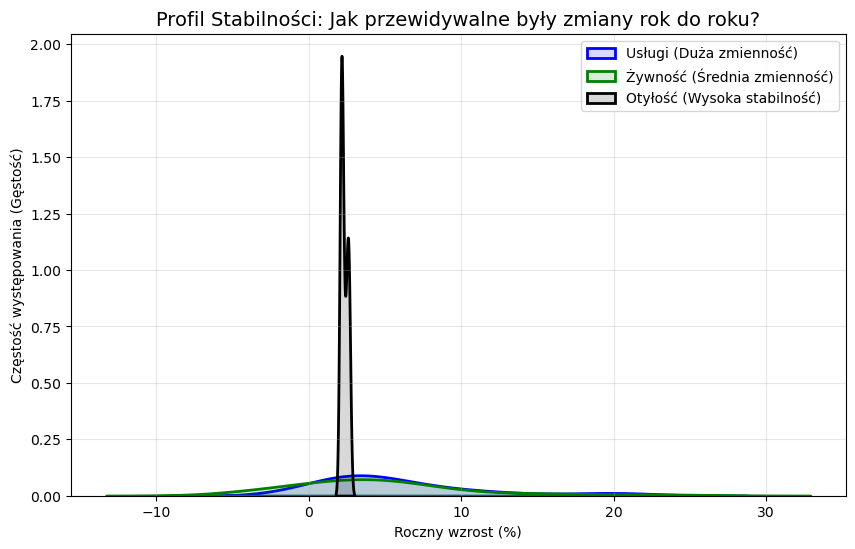

In [19]:
# ROZKŁAD GĘSTOŚCI (KDE)

df_pct = df_final[['Indeks_Spozywczy', 'Indeks_Fryzjer', 'Indeks_Otylosc']].pct_change() * 100
df_pct = df_pct.dropna() 
plt.figure(figsize=(10, 6))

sns.kdeplot(df_pct['Indeks_Fryzjer'], fill=True, color='blue', label='Usługi (Duża zmienność)', alpha=0.15, linewidth=2)
sns.kdeplot(df_pct['Indeks_Spozywczy'], fill=True, color='green', label='Żywność (Średnia zmienność)', alpha=0.15, linewidth=2)
sns.kdeplot(df_pct['Indeks_Otylosc'], fill=True, color='black', label='Otyłość (Wysoka stabilność)', alpha=0.15, linewidth=2)

plt.title('Profil Stabilności: Jak przewidywalne były zmiany rok do roku?', fontsize=14)
plt.xlabel('Roczny wzrost (%)')
plt.ylabel('Częstość występowania (Gęstość)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

**OBSERWACJE - ROZKŁAD GĘSTOŚCI**   
Jeśli chodzi o otyłość to nie występują duże skoki wartości z roku na rok, tylko stabilny wzrost o kilka procent (2-3%). Żywność oraz usługi miały znacznie większe wzrosty rocznie - duża zmienność rynkowa.

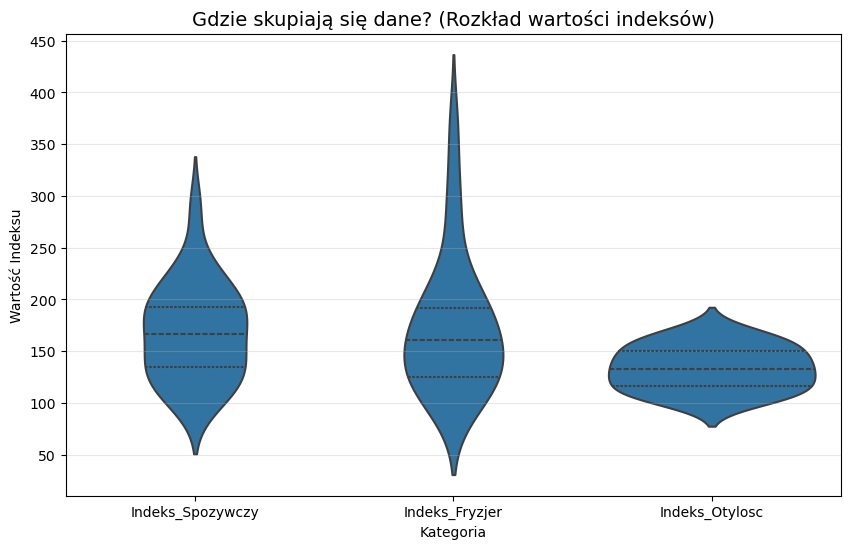

In [24]:
# VIOLIN PLOT (Wykres Skrzypcowy)
plt.figure(figsize=(10, 6))

df_long = df_final[['Indeks_Spozywczy', 'Indeks_Fryzjer', 'Indeks_Otylosc']].melt(var_name='Kategoria', value_name='Wartość Indeksu')

# 2. Rysujemy skrzypce
sns.violinplot(
    data=df_long,
    x='Kategoria',
    y='Wartość Indeksu',
    inner='quartile',
    linewidth=1.5
)

plt.title('Gdzie skupiają się dane? (Rozkład wartości indeksów)', fontsize=14)
plt.grid(True, axis='y', alpha=0.3)
plt.show()

**OBSERWACJE Z WYKRESU SKRZYPCOWEGO**   
Widać, że indeks fryzjerski jest szpiczasty, rozciągnięty w pionie i wąski, co oznacza niestabilność cen, większy wzrost. Indeks spożywczy również, lecz kształt jest już szerszy, bardziej stabilny. Najstabilniejszy jest indeks otyłości, co oznacza stabilny roczny wzrost.

---

In [20]:
print("-" * 60)
print(f"1. Otyłość wzrosła o: {growth_total['Indeks_Otylosc']:.1f}%")
print(f"2. Ceny Usług (Fryzjer) wzrosły o: {growth_total['Indeks_Fryzjer']:.1f}%")
print(f"3. Ceny Żywności wzrosły o: {growth_total['Indeks_Spozywczy']:.1f}%")
print("-" * 60)

------------------------------------------------------------
1. Otyłość wzrosła o: 69.7%
2. Ceny Usług (Fryzjer) wzrosły o: 267.1%
3. Ceny Żywności wzrosły o: 188.6%
------------------------------------------------------------


---
## **WNIOSKI:** ##

**1. Zjawisko relatywnej taniości żywności**   
Mimo że ceny żywności wzrosły o **188,6%**, to wzrost ten jest znacznie wolniejszy niż wzrost cen usług (fryzjer), które podrożały aż o **267,1%**. Oznacza to, że w relacji do kosztów pracy i ogólnego poziomu zamożności, żywność stała się towarem relatywnie tańszym niż dwie dekady temu.

**2. Wzrost siły nabywczej (tanie jedzenie)**   
Analiza wskaźnika siły nabywczej (stosunek ceny usługi do ceny koszyka spożywczego) wykazała trend rosnący. Współczesny konsument za równowartość jednej usługi może nabyć większą ilość żywności niż w 1999 roku. Obniżenie ekonomicznej bariery dostępu do kalorii jest jednym z kluczowych czynników środowiskowych sprzyjających otyłości.

**3. Sztywność popytu i korelacja**   
Zaobserwowano silną korelację dodatnią między wzrostem cen a otyłością. Odsetek osób z otyłością wzrósł w badanym okresie o **69,7%**. Fakt, że społeczeństwo tyje pomimo rosnących cen nominalnych, sugeruje niską elastyczność cenową popytu na żywność – konsumenci nie ograniczają spożycia kalorii w odpowiedzi na inflację, a prawdopodobnie przesuwają konsumpcję w stronę tańszych, przetworzonych produktów.

**Podsumowanie:**   
Polacy tyją, a ceny rosną, jednak kluczem do zrozumienia tego zjawiska nie jest sama drożyzna, lecz fakt, że usługi i praca drożeją szybciej niż jedzenie. Sprawia to, że kalorie stają się relatywnie najłatwiej dostępnym dobrem na rynku.   
**Polacy tyją wolniej niż rosną ceny.**